#### 13.1 图像增广
**大型数据集是成功应用深度神经网络的先决条件**。使用图像增广，课生成相似但不同的训练样本，从而扩大数据集规模，并且能够随即改变训练样本以减少模型对某些属性的依赖，提高模型的泛化能力。

In [1]:
import torch
import torchvision
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt

##### 13.1.1 常用的图像增广方法

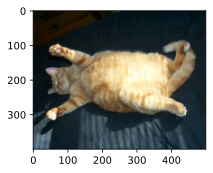

In [4]:
d2l.set_figsize()
img = d2l.Image.open('./img/cat1.jpg')
d2l.plt.imshow(img)

定义辅助函数```apply```，能够在输入图像```img```上多次运行图像增广方法```aug```并显示所有结果。

In [12]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

1. 旋转和裁剪

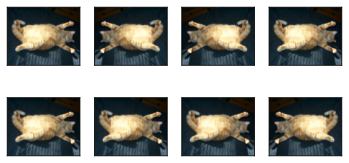

In [ ]:
apply(img, torchvision.transforms.RandomHorizontalFlip())   # 左右翻转

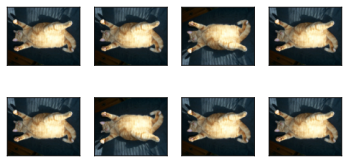

In [15]:
apply(img, torchvision.transforms.RandomVerticalFlip())     # 上下翻转

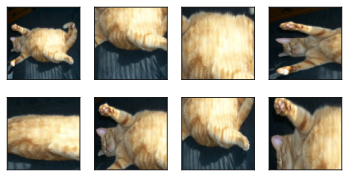

In [ ]:
shape_aug = torchvision.transforms.RandomResizedCrop(       # 随机裁剪
    (200, 200), scale=(0.1, 1), ratio=(0.5, 2))
apply(img, shape_aug)

2. 改变颜色
改变亮度、对比度、饱和度和色调。

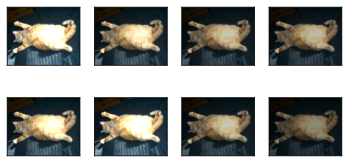

In [ ]:
apply(img, torchvision.transforms.ColorJitter(              # 改变亮度
brightness=0.5, contrast=0, saturation=0, hue=0))

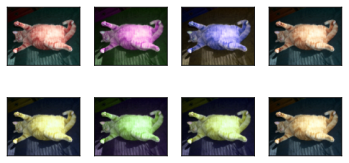

In [19]:
apply(img, torchvision.transforms.ColorJitter(              # 改变色调
brightness=0, contrast=0, saturation=0, hue=0.5))

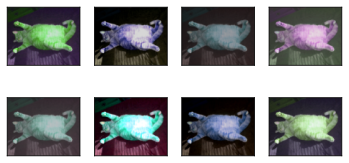

In [22]:
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

3. 结合多种图像增广方法

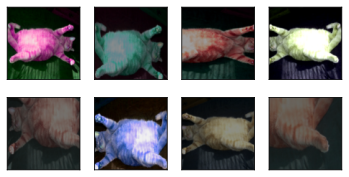

In [23]:
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(), color_aug, shape_aug])
apply(img, augs)

##### 13.1.2 使用图像增广进行训练
使用CIFAR-10数据集，颜色和大小差异更明显。

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

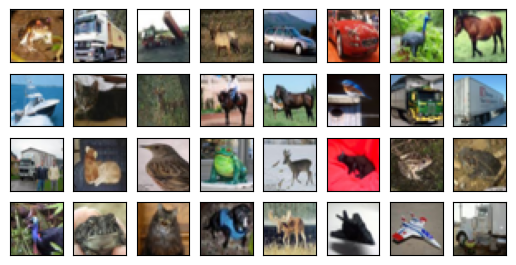

In [8]:
all_images = torchvision.datasets.CIFAR10(train=True, root="../data",
                                        download=True)
d2l.show_images([all_images[i][0] for i in range(32)], 4, 8, scale=0.8)

只对训练样本进行图像增广，且在预测中不适用随即操作的图像增广。

In [9]:
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor()])
test_augs = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()])

定义一个辅助函数，以读取图像和应用图像增广。

In [13]:
def load_cifar10(is_train, augs, batch_size):
    dataset = torchvision.datasets.CIFAR10(root="../data", train=is_train,
                                           transform=augs, download=True)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                    shuffle=is_train, num_workers=d2l.get_dataloader_workers())
    return dataloader

**多GPU训练**：为适配Mac Studio，进行相应修改。

In [18]:
device = torch.device('mps')

torch.set_float32_matmul_precision('high')      # Apple Silicon 高性能设置

def train_batch_ch13(net, X, y, loss, trainer, device): #@save
    """Mac MPS 单GPU高性能训练"""
    if isinstance(X, list):
        X = [x.to(device, non_blocking=True) for x in X]
    else:
        X = X.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.mean().backward()     # l.sum().backward()
    trainer.step()
    with torch.no_grad():
        train_loss_sum = l.sum()
        train_acc_sum = d2l.accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, device=device):   #@save
    """Mac Studio M3 Ultra MPS 训练"""
    timer, num_batches = d2l.Timer(), len(train_iter)
    animator = d2l.Animator(
        xlabel='epoch',
        xlim=[1, num_epochs],
        ylim=[0, 1],
        legend=['train loss', 'train acc', 'test acc']
    )
    net = net.to(device)
    print(f'Using device: {device}')
    for epoch in range(num_epochs):
        # train_loss, train_acc, num_examples, num_preds
        metric = d2l.Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(net, features, labels, loss, trainer, device)
            metric.add( l, acc, labels.shape[0], labels.numel())
            timer.stop()

            if ((i + 1) % max(1, num_batches // 5) == 0 or i == num_batches - 1):
                animator.add( epoch + (i + 1) / num_batches,
                            (metric[0] / metric[2], metric[1] / metric[3], None))

        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter, device=device)
        animator.add( epoch + 1, (None, None, test_acc))
    
    print(
        f'loss {metric[0] / metric[2]:.3f}, '
        f'train acc {metric[1] / metric[3]:.3f}, '
        f'test acc {test_acc:.3f}')
    print(
        f'{metric[2] * num_epochs / timer.sum():.1f} '
        f'examples/sec on {device}')

定义```train_with_data_aug```函数，使用图像增广来训练模型。该函数使用Adam算法作为训练的优化算法。

In [18]:
batch_size, devices, net = 512, device, d2l.resnet18(10, 3) # 使用ResNet

def init_weights(m):
    if type(m) in [nn.Linear, nn.Conv2d]:
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights)

def train_with_data_aug(train_augs, test_augs, net, lr=0.002):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction="none")
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, 10, device)

loss 0.202, train acc 0.929, test acc 0.845
3038.0 examples/sec on mps


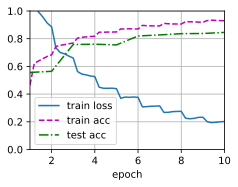

In [ ]:
train_with_data_aug(train_augs, test_augs, net) # batch_size, lr = 256, 0.001

loss 0.339, train acc 0.881, test acc 0.746
3264.0 examples/sec on mps


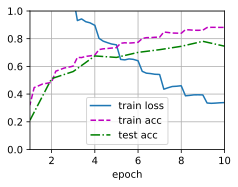

In [19]:
train_with_data_aug(train_augs, test_augs, net) # batch_size, lr = 512, 0.002

#### 13.2 微调
**迁移学习（Transfer Learning）**：将源数据数据集学习的知识迁移到目标数据集，以降低数据集收集成本。
##### 13.2.1 步骤
**微调（Fine-Tuning）**：迁移学习的常见技巧，包括：
- 在源数据集上预训练神经网络模型，即**源模型**；
- 创建一个新的神经网络模型，即**目标模型**，这将复制源模型上的所有模型设计及其参数。假设这些模型参数包含从源数据集上学习的知识同样适用于目标数据集，并且源模型的输出层与源数据集的标签密切相关，故不在目标模型中使用该层；
- 向目标模型中添加输出层，其输出数是目标数据集中的类别数，然后随机初始化该层的模型参数；
- 在目标数据集上训练模型，输出层从头开始进行训练，其他所有层的参数将根据源模型的参数进行微调。

##### 13.2.2 热狗识别
通过热狗识别来演示微调，在一个小型数据上微调ResNet模型。

In [5]:
import os
import torch
import torchvision
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt

1. 获取数据集

包含1400张热狗的“正类”和其他“负类”。

In [3]:
#@save
d2l.DATA_HUB['hotdog'] = (d2l.DATA_URL + 'hotdog.zip',
                         'fba480ffa8aa7e0febbb511d181409f899b9baa5')

data_dir = d2l.download_extract('hotdog')

In [6]:
train_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'))
test_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'test'))

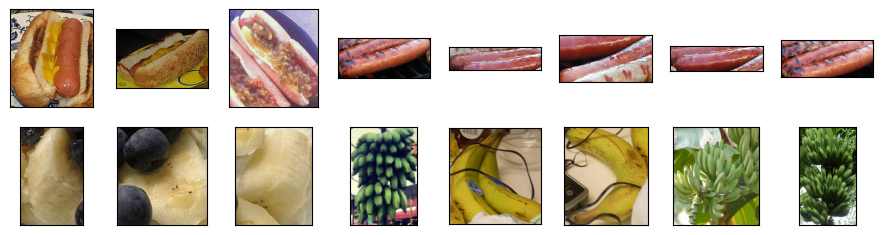

In [7]:
hotdogs = [train_imgs[i][0] for i in range(8)]
not_hotdogs = [train_imgs[-i - 1][0] for i in range(8)]
d2l.show_images(hotdogs + not_hotdogs, 2, 8, scale=1.4);

从图像中裁剪随即大小和随机长宽比的区域，缩放为224×224的输入图像。对于RGB颜色通道，分别标准化每个通道，集该通道的每个值减去该通道的均值，结果除以标准差。

In [8]:
# 使用RGB通道的均值和标准差，以标准化每个通道
normalize = torchvision.transforms.Normalize(
    [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    normalize])

test_augs = torchvision.transforms.Compose([
    torchvision.transforms.Resize([256, 256]),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    normalize])

2. 定义和初始化模型

使用预训练的ResNet-18作为源模型。

In [9]:
pretrained_net = torchvision.models.resnet18(pretrained=True)

/opt/anaconda3/envs/d2l/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/d2l/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/zhangweixuan_private/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


In [12]:
pretrained_net.fc   # 预训练的源模型示例包含输出层fc

Linear(in_features=512, out_features=1000, bias=True)

目标模型```finetune_net```中成员变量```featres```的参数被初始化为源模型相应层的模型参数，可以使用较低的学习率进行微调。

In [13]:
finetune_net= torchvision.models.resnet18(pretrained=True)
finetune_net.fc = nn.Linear(finetune_net.fc.in_features, 2)
nn.init.xavier_uniform_(finetune_net.fc.weight);

/opt/anaconda3/envs/d2l/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/d2l/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


3. 微调模型

定义一个```train_fine_tuning```实现微调，多次调用。

In [22]:
# 如果param_group=True，输出层中的模型参数将使用十倍的学习率
def train_fine_tuning(net, learning_rate, batch_size=256, num_epochs=20,
                      param_group=True):
    train_iter = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(
        os.path.join(data_dir, 'train'), transform=train_augs),
        batch_size=batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(torchvision.datasets.ImageFolder(
        os.path.join(data_dir, 'test'), transform=test_augs),
        batch_size=batch_size)
    devices = torch.device('mps')
    loss = nn.CrossEntropyLoss(reduction="none")
    if param_group:
        params_1x = [param for name, param in net.named_parameters()
             if name not in ["fc.weight", "fc.bias"]]
        trainer = torch.optim.SGD([{'params': params_1x},
                                   {'params': net.fc.parameters(),
                                    'lr': learning_rate * 10}],
                                lr=learning_rate, weight_decay=0.001)
    else:
        trainer = torch.optim.SGD(net.parameters(), lr=learning_rate,
                                  weight_decay=0.001)
    train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
                   devices)

loss 0.504, train acc 0.754, test acc 0.770
731.5 examples/sec on mps


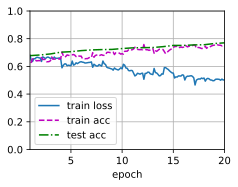

In [23]:
train_fine_tuning(finetune_net, 5e-5)

对比：相同的模型，单模型初始化为随机值。

loss 0.536, train acc 0.802, test acc 0.789
762.3 examples/sec on mps


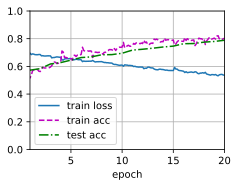

In [24]:
scratch_net = torchvision.models.resnet18()
scratch_net.fc = nn.Linear(scratch_net.fc.in_features, 2)
train_fine_tuning(scratch_net, 5e-4, param_group=False)